In [ ]:
!unzip -q iterative_povm_optim.zip

In [ ]:
import torch

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from iterative_povm_optim.core.povm_cholesky_lbfgs_rounds import QuantumMulticlassClassifier
from iterative_povm_optim.core.utils import *

from iterative_povm_optim.dataset import RhoDataset

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
img_dim = 8
dataset = RhoDataset(image_size=(img_dim, img_dim),
                     blur_kernel_size=2,
                     blur_sigma=0.5,
                     device=device)

classes = [0, 1, 2, 3, 4]
n_classes = len(classes)
n_per_class = 100

rhos_by_class, vectors_by_class = dataset.density_matrices_by_class(classes, n_per_class)

d = dataset.dimension()
# vectors = dataset.flattened_vectors()
# labels = dataset.labels_tensor()

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 517kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.79MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.57MB/s]
Creating density matrices...: 100%|██████████| 5/5 [00:01<00:00,  3.97it/s]


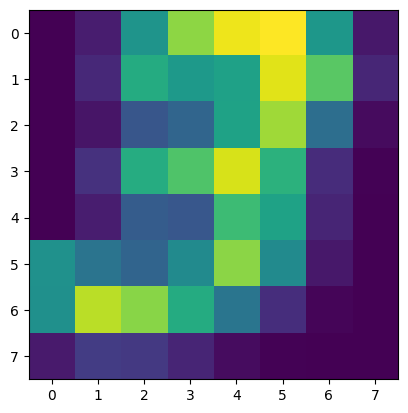

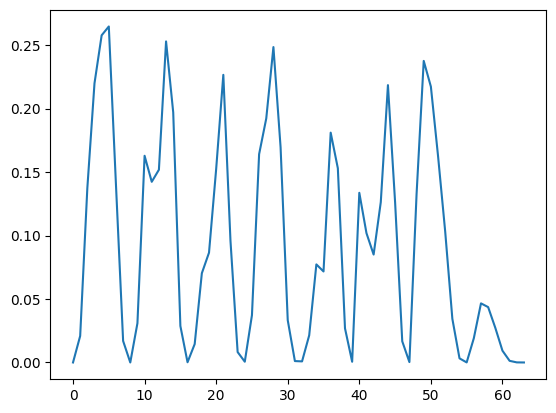

In [ ]:
cls = 3
idx = 0

plt.imshow(vectors_by_class[cls][idx].detach().cpu().numpy().reshape(img_dim, img_dim))
plt.show()

plt.plot(vectors_by_class[cls][idx].detach().cpu().numpy())
plt.show()

In [ ]:
classifier = QuantumMulticlassClassifier(
             d,
             n_classes,
             povm_rank=None,
             warm_start=True)

k_values = list(int(n) for n in np.arange(1, 21, 2))

results = classifier.optimize(
          rhos_by_class,
          k_values,
          num_epochs=200,
          lr=0.1,
          grad_tol=1e-8,
          cross_k_restarts=False # set to True if you want to initialise from all prior optimised measurements
          )

round 2/5 k=9 start=adopt_k11 [1/1]:  36%|███▌      | 71/200 [01:04<01:56,  1.11it/s, best_overall=-1.00000000, epoch=71, grad=1.76e-05, success=0.80518593]


In [ ]:
results["best_povms"].keys()

dict_keys([1, 3, 5, 7, 9, 11, 13, 15, 17, 19])

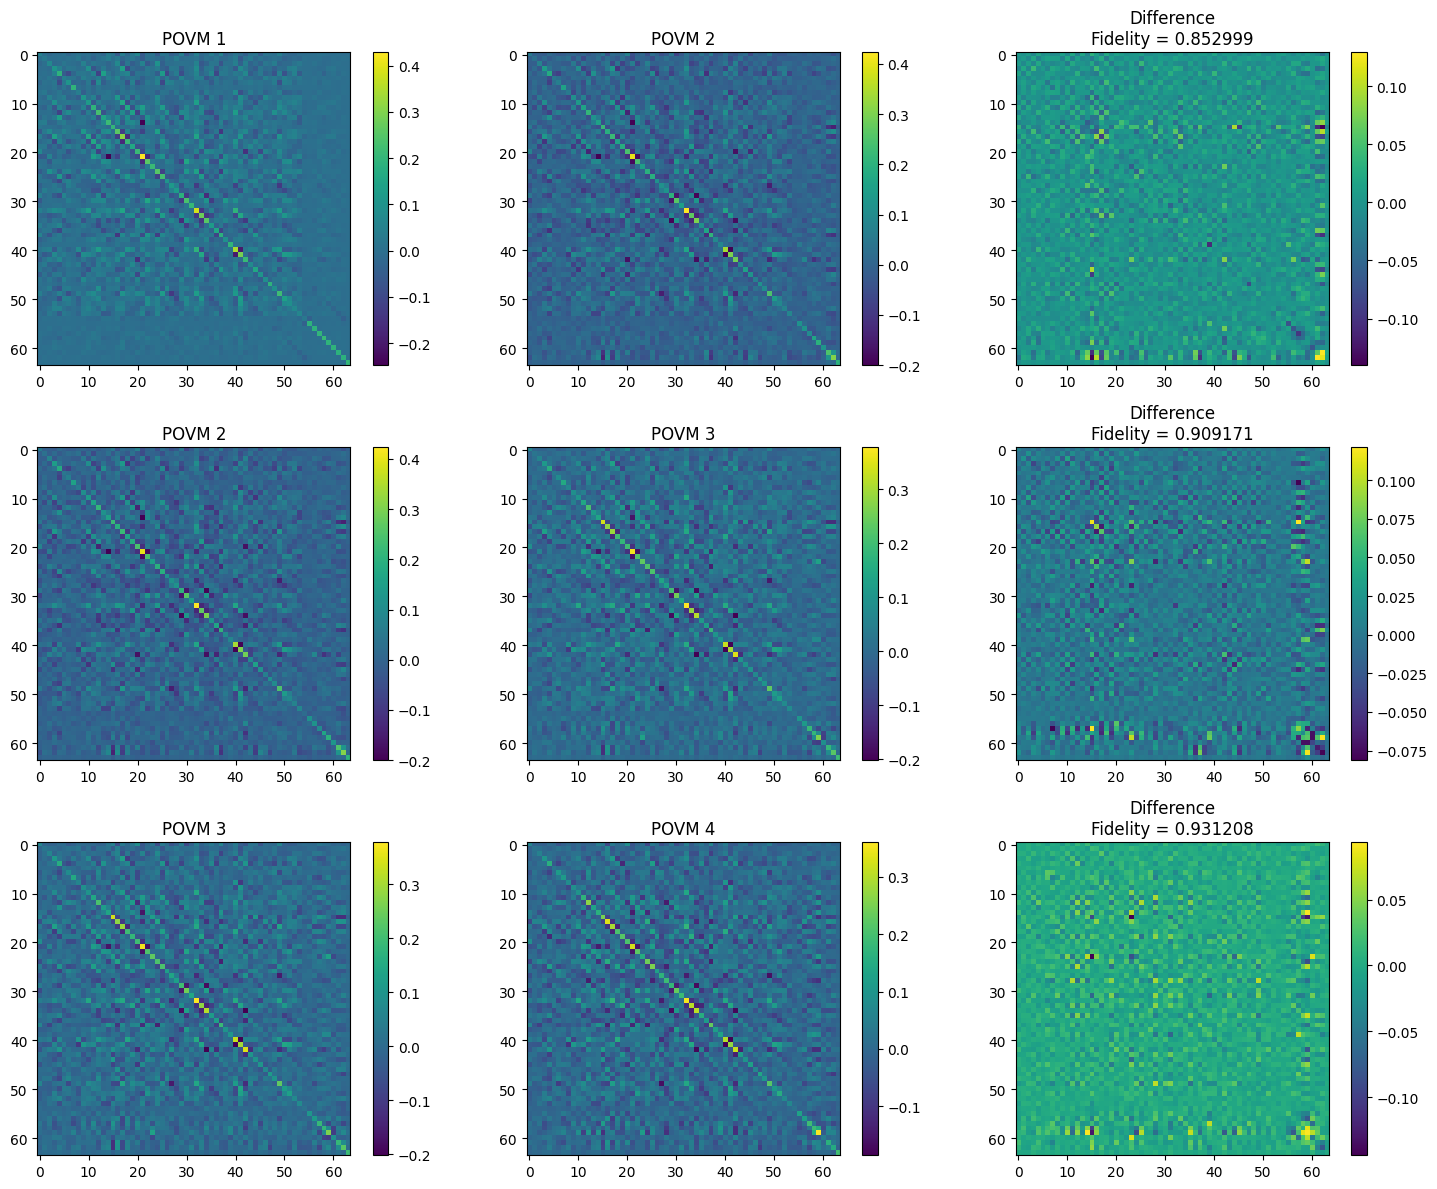

In [ ]:
def sqrt_psd(A):
    vals, vecs = np.linalg.eigh(A)
    vals = np.clip(vals, 0, None)  # remove tiny negatives
    return vecs @ np.diag(np.sqrt(vals)) @ vecs.conj().T

# fidelity between two povms
def povm_element_fidelity(E1, E2):
    E1n = E1 / np.trace(E1)
    E2n = E2 / np.trace(E2)

    sqrtE1 = sqrt_psd(E1n)
    middle = sqrtE1 @ E2n @ sqrtE1
    sqrt_middle = sqrt_psd(middle)

    return np.real(np.trace(sqrt_middle)**2)

# get keys for povms
best_povms_keys = list(results["best_povms"].keys())

# plotting
n = 3
fig, axes = plt.subplots(n, 3, figsize=(15, n*4))

for i in range(n):
    povm1 = results["best_povms"][best_povms_keys[i]][0]
    povm2 = results["best_povms"][best_povms_keys[i+1]][0]
    diff = povm2 - povm1

    fidelity = povm_element_fidelity(povm1, povm2)

    im0 = axes[i, 0].imshow(np.real(povm1))
    axes[i, 0].set_title(f"POVM {i+1}")
    plt.colorbar(im0, ax=axes[i, 0])

    im1 = axes[i, 1].imshow(np.real(povm2))
    axes[i, 1].set_title(f"POVM {i+2}")
    plt.colorbar(im1, ax=axes[i, 1])

    im2 = axes[i, 2].imshow(np.real(diff))
    axes[i, 2].set_title(f"Difference\nFidelity = {fidelity:.6f}")
    plt.colorbar(im2, ax=axes[i, 2])

plt.tight_layout()
plt.show()

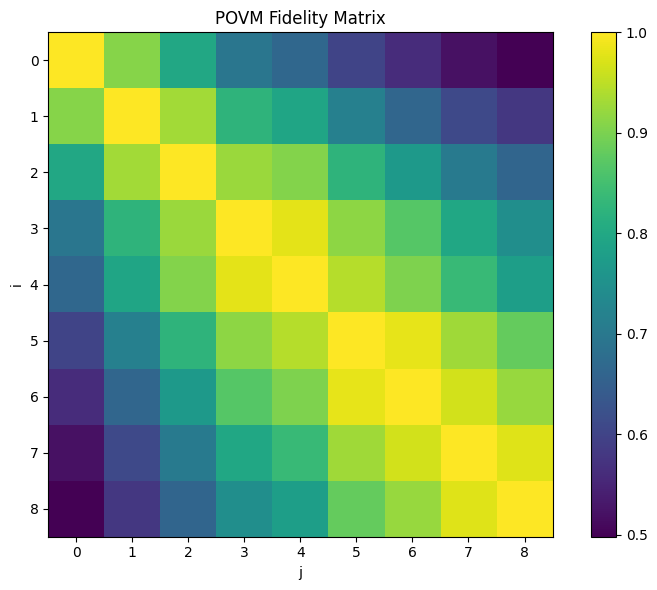

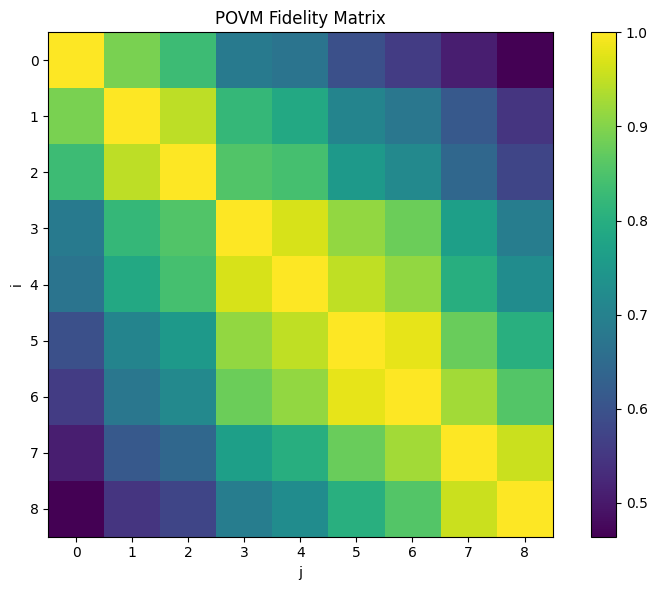

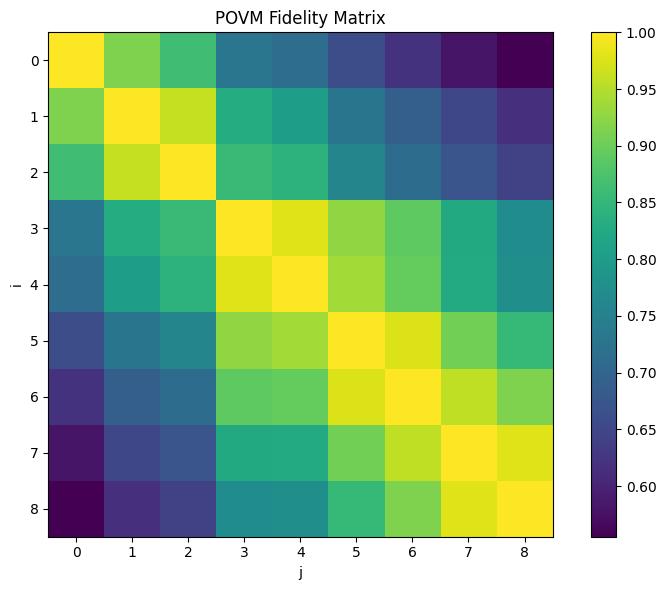

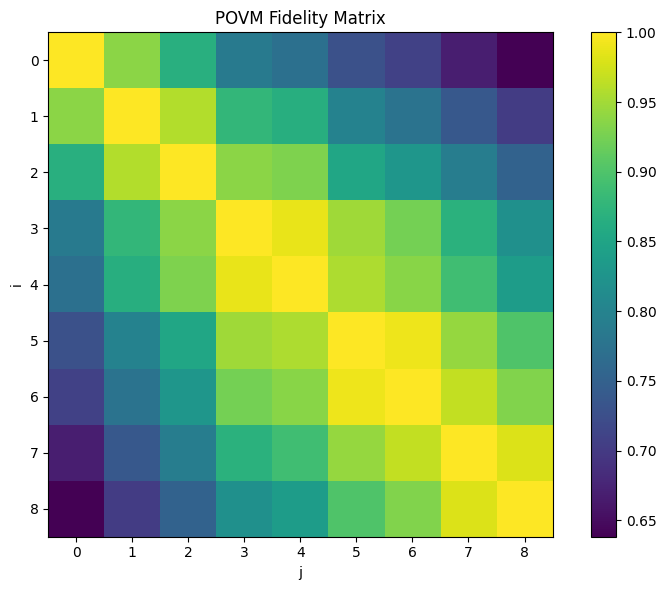

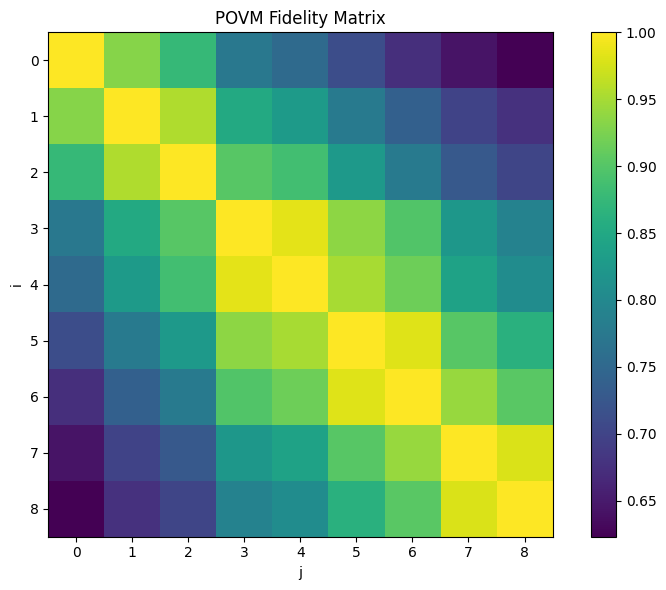

In [ ]:
for idx in range(len(classes)):
    N = len(results["best_povms"]) - 1

    # build fidelity matrix
    F_matrix = np.zeros((N, N))

    for i in range(1, N+1):
        Ei = results["best_povms"][best_povms_keys[i]][idx]
        for j in range(1, N+1):
            Ej = results["best_povms"][best_povms_keys[j]][idx]
            F_matrix[i-1, j-1] = povm_element_fidelity(Ei, Ej)

    # plot
    plt.figure(figsize=(8, 6))
    im = plt.imshow(F_matrix)
    plt.colorbar(im)

    plt.title("POVM Fidelity Matrix")
    plt.xlabel("j")
    plt.ylabel("i")

    plt.xticks(range(N))
    plt.yticks(range(N))

    plt.tight_layout()
    plt.show()

In [ ]:
from iterative_povm_optim.analysis.metrics import *
from iterative_povm_optim.analysis.visuals import *

In [ ]:
cls_to_view = 1

keys = results["best_povms"].keys()
povms_to_view = []
for key in keys:
    povms_to_view.append(results["best_povms"][key][cls_to_view])

imgs = vectors_by_class[cls_to_view].cpu().detach().numpy()

# make viewer
povm_viewer(povms_to_view,
            imgs,
            (img_dim, img_dim),
            D=2,
            tol=0.02)

interactive(children=(IntSlider(value=0, continuous_update=False, description='k:', max=9), Output()), _dom_cl…

In [ ]:
wrong_cls_idx = 0
wrong_imgs = vectors_by_class[wrong_cls_idx].cpu().detach().numpy()

histogram_viewer(povms=povms_to_view,
                 correct_imgs=imgs,
                 wrong_imgs=wrong_imgs,
                 D=2)

interactive(children=(IntSlider(value=0, continuous_update=False, description='k:', max=9), Output()), _dom_cl…

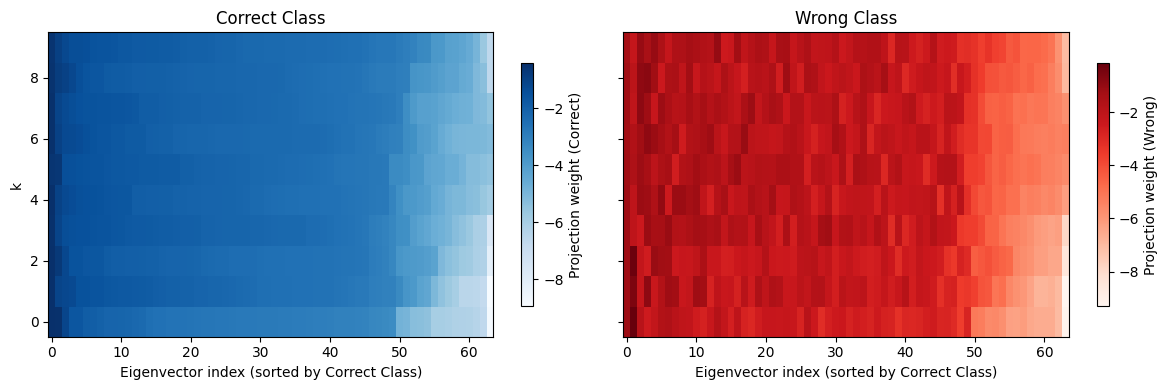

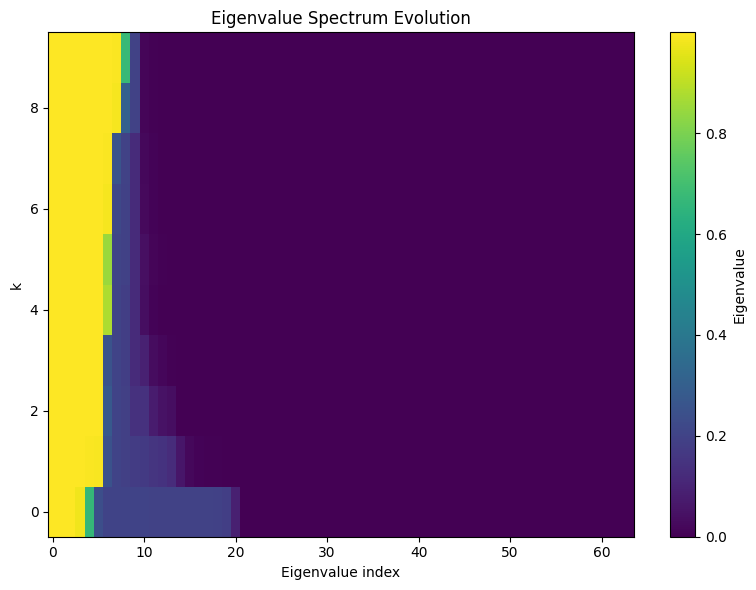

In [ ]:
projection_heatmap(povms_to_view,
                   imgs,
                   wrong_imgs,
                   log_scale=True)

eigenvalue_spectrum_heatmap(povms_to_view, log_scale=False)

In [ ]:
from tqdm import tqdm

keys = results["best_povms"].keys()
povms_list = []
for key in keys:
    povms_list.append(results["best_povms"][key])

vectors_list = [_.cpu().detach().numpy() for _ in vectors_by_class]

k_max = len(povms_list)

# store results
diagonal_success = []
success_matrix = np.zeros((k_max, k_max))

for idx, k_train in enumerate(tqdm(keys)):

    povm = povms_list[idx]

    # evaluate this POVM on all k = 1..k_max
    results = compute_success_vs_k(
        povm,
        vectors_list,
        keys
    )

    success_curve = np.array(results["overall_success"])

    # store success probabilities
    diagonal_success.append(success_curve[idx])
    success_matrix[idx, :] = success_curve

diagonal_success = np.array(diagonal_success)

100%|██████████| 10/10 [00:03<00:00,  3.05it/s]


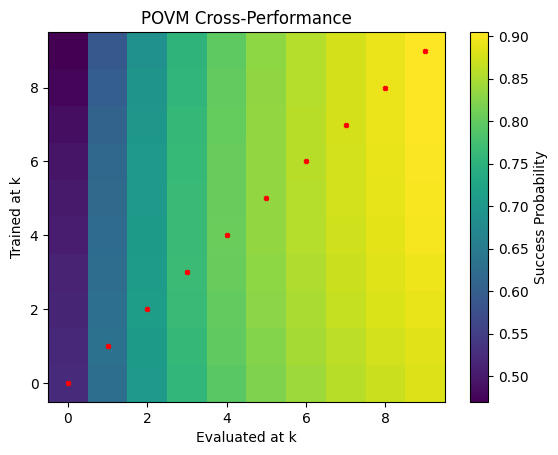

In [ ]:
fig, ax = plt.subplots()
im = ax.imshow(success_matrix, origin="lower", aspect="auto")
plt.colorbar(im, ax=ax, label="Success Probability")
ax.set_xlabel("Evaluated at k")
ax.set_ylabel("Trained at k")
ax.set_title("POVM Cross-Performance")

# find and mark the maximum value in each column
n_cols = success_matrix.shape[1]
for col in range(n_cols):
    row = np.argmax(success_matrix[:, col])
    ax.plot(col, row, 'rx', markersize=3, markeredgewidth=2)

plt.show()

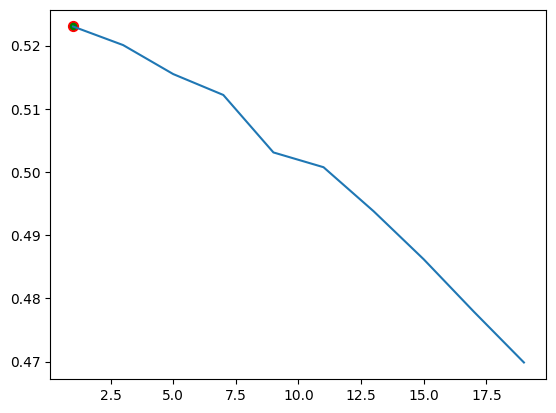

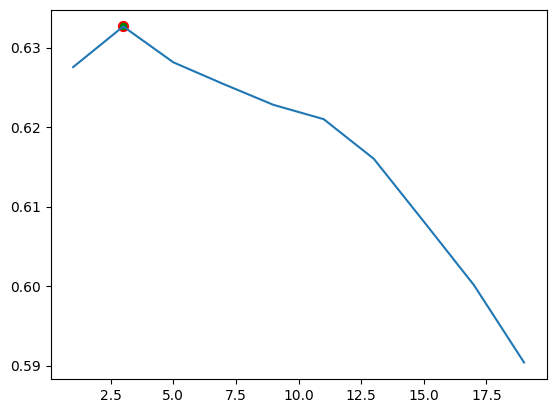

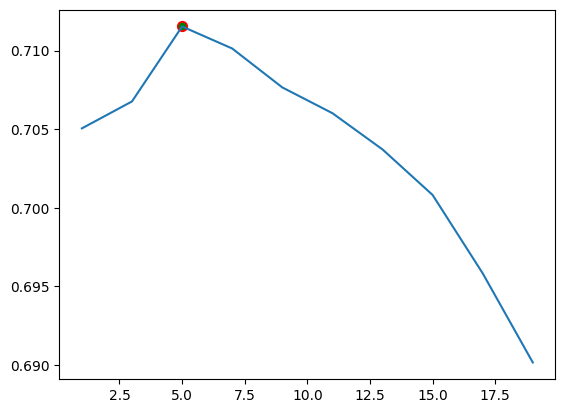

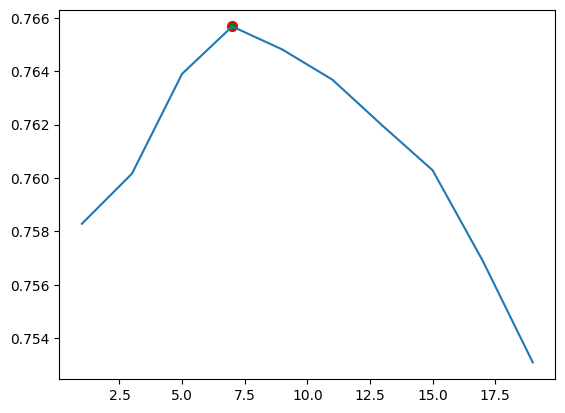

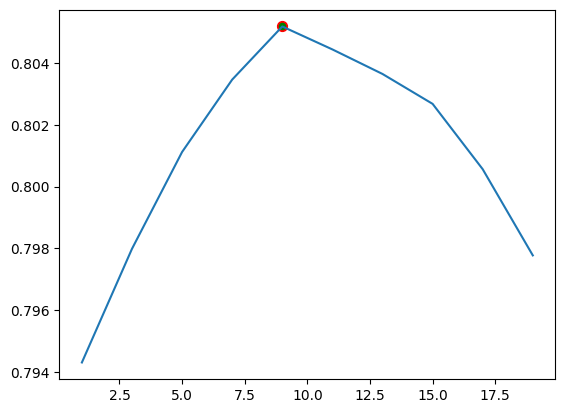

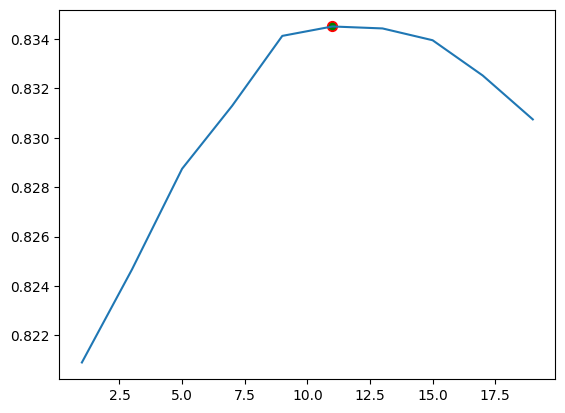

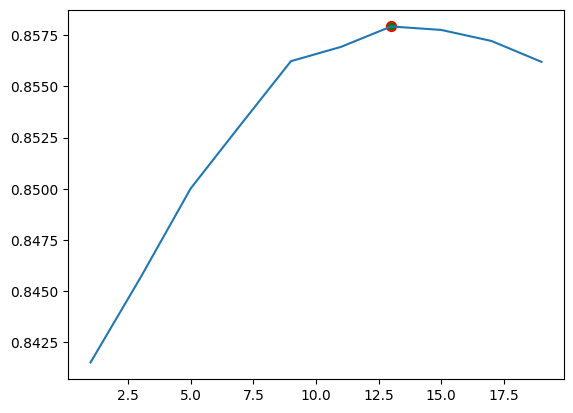

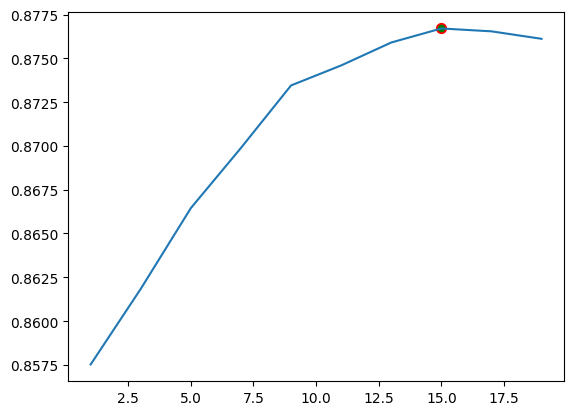

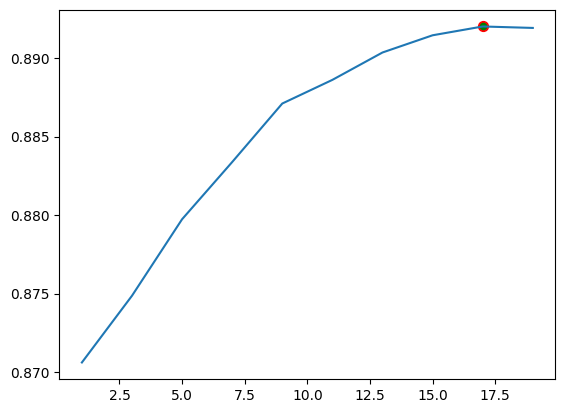

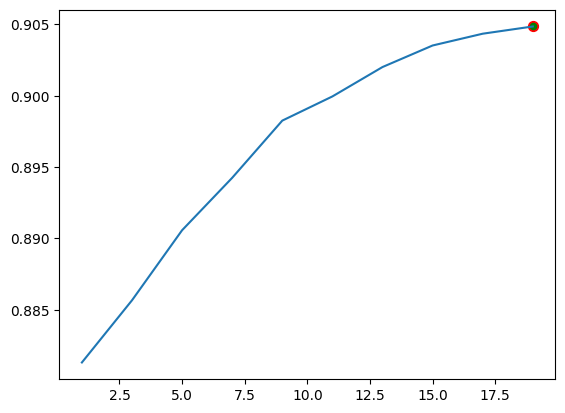

In [ ]:
for idx, k in enumerate(keys):
    # trained measurement
    plt.scatter(
        k,
        success_matrix[idx, idx],
        s=50,
        c="r",
        zorder=1
    )

    # highest accuracy measurement
    plt.scatter(
        2*np.argmax(success_matrix[:, idx]) + 1,
        np.max(success_matrix[:, idx]),
        s=20,
        c="g",
        zorder=2
    )

    plt.plot(keys, success_matrix[:, idx], zorder=3)
    plt.show()

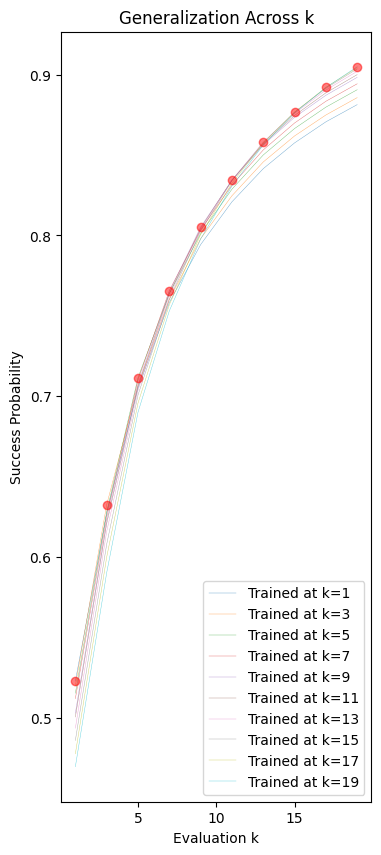

In [ ]:
plt.figure(figsize=(4, 10))

for idx, k_train in enumerate(keys):
    plt.plot(
        keys,
        success_matrix[idx],
        label=f"Trained at k={k_train}",
        alpha=0.7,
        lw=0.3
    )

plt.plot(keys, diagonal_success, "o", c="red", alpha=0.5)

plt.xlabel("Evaluation k")
plt.ylabel("Success Probability")
plt.legend()
plt.title("Generalization Across k")
plt.show()

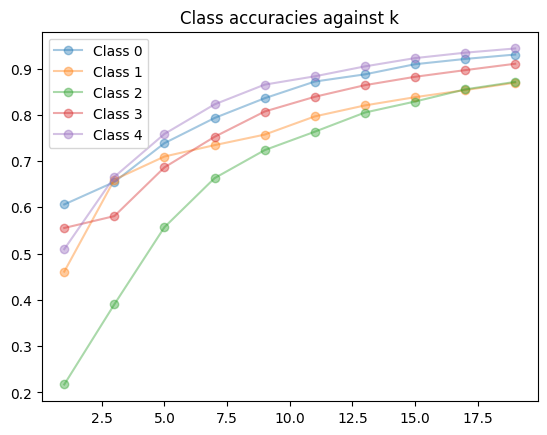

In [ ]:
cls_keys = results["per_class_success"].keys()
for key in cls_keys:
    plt.plot(results["k_values"], results["per_class_success"][key], "-o", label=f"Class {key}", alpha=0.4)
plt.title("Class accuracies against k")
plt.legend()
plt.show()